# msmapper
read and plot reciprocal lattice files

**By Dan Porter, September 2024**

### Running msmapper
Example terminal code to run from a Diamond Linux workstation:
``` bash
$ cd /dls/i16/data/20XX/mm12345-1
$ module load msmapper
$ rs_map -s 0.002 --monitor rc -o processing/12345_remap.nxs 12345.nxs
```

### Read msmapper output

In [4]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import h5py

file = 'data/processing/1041304_rsmap.nxs'
filename = os.path.basename(file)

with h5py.File(file, 'r') as hdf:
    # the following are links to the original scan file
    scan_command = hdf['/entry0/scan_command'].asstr()[()]  # str
    crystal = hdf['/entry0/before_scan/xtlinfo_extra/crystal_name'][()]  # str
    temp = hdf['/entry0/before_scan/temperature_controller/Tsample'][()]  # float
    unit_cell = np.reshape(hdf['/entry0/sample/unit_cell'], -1)  # 1D array, length 6
    energy = hdf['/entry0/sample/beam/incident_energy'][0]  # # float
    ubmatrix = hdf['/entry0/sample/ub_matrix'][0]  # 3D array, shape (3,3)
    # this is the processed data
    haxis = hdf['/processed/reciprocal_space/h-axis'][()]  # 1D array, length n
    kaxis = hdf['/processed/reciprocal_space/k-axis'][()]  # 1D array, length m
    laxis = hdf['/processed/reciprocal_space/l-axis'][()]  # 1D array, length o
    volume = hdf['/processed/reciprocal_space/volume'][()]  # 3D array, shape [n,m,o]

print(f"Loaded file: {filename} with volume shape: {volume.shape}")

Loaded file: 1041304_rsmap.nxs with volume shape: (100, 100, 100)


In [2]:
# average angle subtended by each pixel
pixel_size = 0.172 # mm
detector_distance = 565 # mm
solid_angle = pixel_size ** 2 / detector_distance ** 2  # sr
print(f'Each pixel is normalised by the solid angle: {solid_angle: .4g} sr')

volume = volume * solid_angle

Each pixel is normalised by the solid angle:  9.267e-08 sr


### Plot summed slices

Text(0, 0.5, 'sum axes [0,1]')

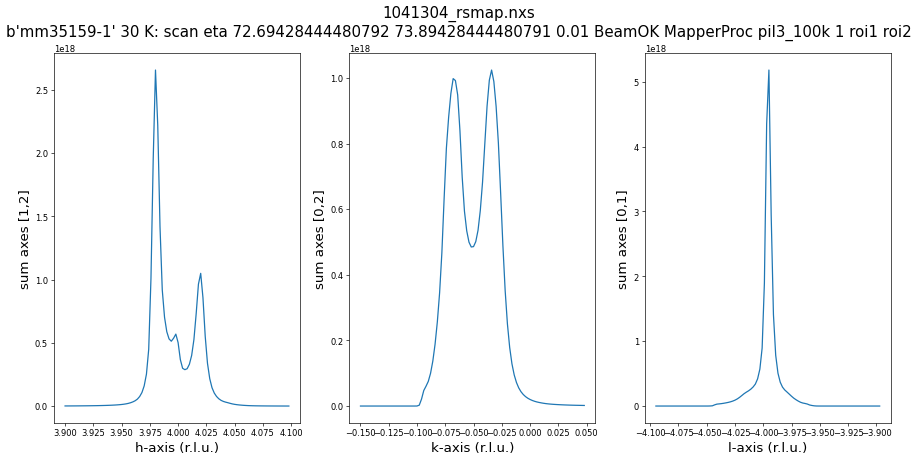

In [5]:
# Plot summed cuts
plt.figure(figsize=[18, 8], dpi=60)
title = f"{filename}\n{crystal} {temp:.3g} K: {scan_command}"
plt.suptitle(title, fontsize=18)

plt.subplot(131)
plt.plot(haxis, volume.sum(axis=1).sum(axis=1))
plt.xlabel('h-axis (r.l.u.)', fontsize=16)
plt.ylabel('sum axes [1,2]', fontsize=16)

plt.subplot(132)
plt.plot(kaxis, volume.sum(axis=0).sum(axis=1))
plt.xlabel('k-axis (r.l.u.)', fontsize=16)
plt.ylabel('sum axes [0,2]', fontsize=16)

plt.subplot(133)
plt.plot(laxis, volume.sum(axis=0).sum(axis=0))
plt.xlabel('l-axis (r.l.u.)', fontsize=16)
plt.ylabel('sum axes [0,1]', fontsize=16)

### Plot summed images 

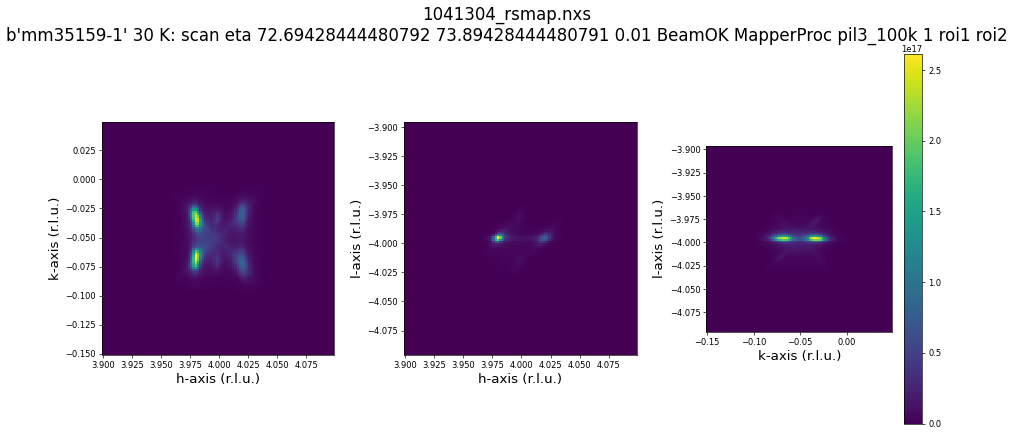

In [6]:
# Plot summed images
plt.figure(figsize=[18, 8], dpi=60)
title = f"{filename}\n{crystal} {temp:.3g} K: {scan_command}"
plt.suptitle(title, fontsize=20)
plt.subplots_adjust(wspace=0.3)

plt.subplot(131)
K, H = np.meshgrid(kaxis, haxis)
plt.pcolormesh(H, K, volume.sum(axis=2), shading='auto')
plt.xlabel('h-axis (r.l.u.)', fontsize=16)
plt.ylabel('k-axis (r.l.u.)', fontsize=16)
plt.axis('image')
#plt.colorbar()

plt.subplot(132)
L, H = np.meshgrid(laxis, haxis)
plt.pcolormesh(H, L, volume.sum(axis=1), shading='auto')
plt.xlabel('h-axis (r.l.u.)', fontsize=16)
plt.ylabel('l-axis (r.l.u.)', fontsize=16)
plt.axis('image')
#plt.colorbar()

plt.subplot(133)
L, K = np.meshgrid(laxis, kaxis)
plt.pcolormesh(K, L, volume.sum(axis=0), shading='auto')
plt.xlabel('k-axis (r.l.u.)', fontsize=16)
plt.ylabel('l-axis (r.l.u.)', fontsize=16)
plt.axis('image')
plt.colorbar()

### Convert h,k,l to cartesian basis (in units of inverse-Angstroms)

In [7]:
# Functions from Dans_Diffraction (https://github.com/DanPorter/Dans_Diffraction)
def latpar2uv(a, b, c, alpha, beta, gamma):
    # From http://pymatgen.org/_modules/pymatgen/core/lattice.html
    alpha_r = np.radians(alpha)
    beta_r = np.radians(gamma)
    gamma_r = np.radians(beta)
    val = (np.cos(alpha_r) * np.cos(beta_r) - np.cos(gamma_r)) \
          / (np.sin(alpha_r) * np.sin(beta_r))
    # Sometimes rounding errors result in values slightly > 1.
    val = abs(val)
    gamma_star = np.arccos(val)
    aa = [a * np.sin(beta_r), a * np.cos(beta_r), 0.0]
    bb = [0.0, b, 0.0]
    cc = [-c * np.sin(alpha_r) * np.cos(gamma_star),
          c * np.cos(alpha_r),
          c * np.sin(alpha_r) * np.sin(gamma_star)]

    return np.round(np.array([aa, bb, cc]), 8)

def RcSp(UV):
    """
    Generate reciprocal cell from real space unit vecors
    Usage:
    UVs = RcSp(UV)
      UV = [[3x3]] matrix of vectors [a,b,c]
    """
    UVs = 2 * np.pi * np.linalg.inv(UV).T
    return UVs

def genq(h, k, l, UVstar):
    """convert arrays of hkl into cartesian basis mesh using recirprocal basis UVstar"""
    avec, bvec, cvec = UVstar
    kk, hh, ll = np.meshgrid(k, h, l)
    shape = np.shape(hh)
    q = avec * hh.reshape(-1, 1) + bvec * kk.reshape(-1, 1) + cvec * ll.reshape(-1, 1)
    qx = q[:, 0].reshape(shape)
    qy = q[:, 1].reshape(shape)
    qz = q[:, 2].reshape(shape)
    return qx, qy, qz

def cal2theta(qmag, energy_kev=17.794):
    """
    Calculate theta at particular energy in keV from |Q|
     twotheta = cal2theta(Qmag,energy_kev=17.794)
    """
    h = 6.62606868E-34  # Js  Plank consant
    c = 299792458  # m/s   Speed of light
    e = 1.6021733E-19  # C  electron charge
    energy = energy_kev * 1000.0  # energy in eV
    # Calculate 2theta angles for x-rays
    twotheta = 2 * np.arcsin(qmag * 1e10 * h * c / (energy * e * 4 * np.pi))
    # return x2T in degrees
    twotheta = twotheta * 180 / np.pi
    return twotheta

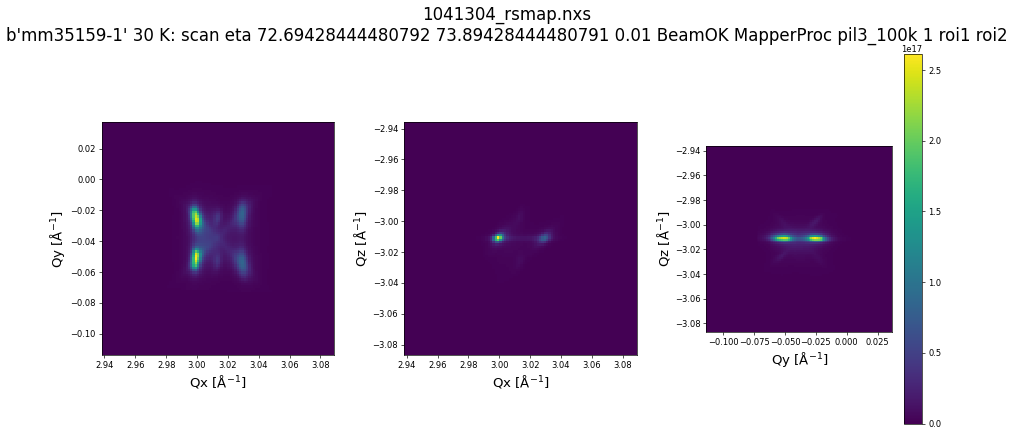

In [8]:
# Convert to Q - normal basis in units of A^-1 
a, b, c, alpha, beta, gamma = unit_cell
astar, bstar, cstar = RcSp(latpar2uv(a, b, c, alpha, beta, gamma))
qx, qy, qz = genq(haxis, kaxis, laxis, [astar, bstar, cstar])

# Plot summed images
plt.figure(figsize=[18, 8], dpi=60)
title = f"{filename}\n{crystal} {temp:.3g} K: {scan_command}"
plt.suptitle(title, fontsize=20)
plt.subplots_adjust(wspace=0.3)

plt.subplot(131)
plt.pcolormesh(qx.mean(axis=2), qy.mean(axis=2), volume.sum(axis=2), shading='auto')
plt.xlabel(u'Qx [\u212b$^{-1}$]', fontsize=16)
plt.ylabel(u'Qy [\u212b$^{-1}$]', fontsize=16)
plt.axis('image')
#plt.colorbar()

plt.subplot(132)
plt.pcolormesh(qx.mean(axis=1), qz.mean(axis=1), volume.sum(axis=1), shading='auto')
plt.xlabel(u'Qx [\u212b$^{-1}$]', fontsize=16)
plt.ylabel(u'Qz [\u212b$^{-1}$]', fontsize=16)
plt.axis('image')
#plt.colorbar()

plt.subplot(133)
plt.pcolormesh(qy.mean(axis=0), qz.mean(axis=0), volume.sum(axis=0), shading='auto')
plt.xlabel(u'Qy [\u212b$^{-1}$]', fontsize=16)
plt.ylabel(u'Qz [\u212b$^{-1}$]', fontsize=16)
plt.axis('image')
plt.colorbar()

### |Q| and Two-Theta plots

C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0, 0.5, 'Intensity')

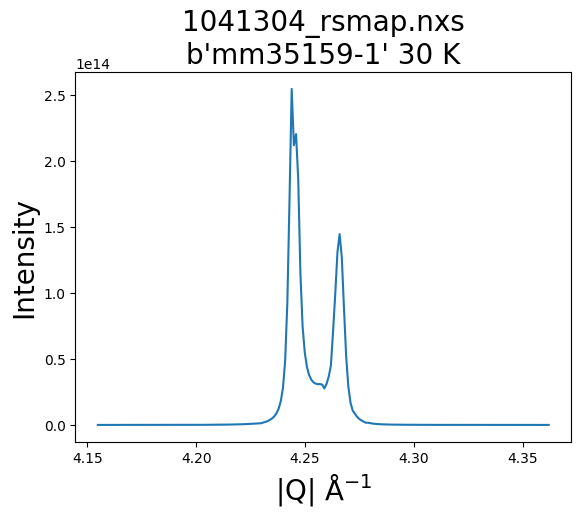

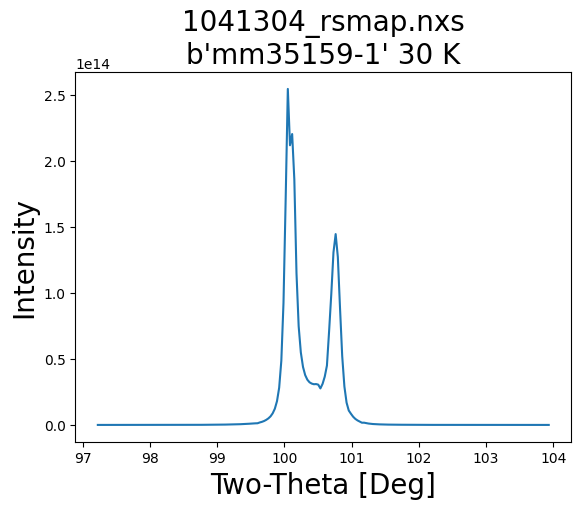

In [9]:
# Convert to Q - normal basis in units of A^-1 
a, b, c, alpha, beta, gamma = unit_cell
astar, bstar, cstar = RcSp(latpar2uv(a, b, c, alpha, beta, gamma))
qx, qy, qz = genq(haxis, kaxis, laxis, [astar, bstar, cstar])
qmag = np.sqrt(qx **2 + qy ** 2 + qz **2).reshape(-1)
qvol = volume.reshape(-1)

# bin volume
bin_cen = np.arange(qmag.min(), qmag.max(), 0.001)
bin_edge = bin_cen + 0.005
bin_pos = np.digitize(qmag, bin_edge) -1
bin_sum = [np.mean(qvol[bin_pos==n]) for n in range(len(bin_cen))]
tth = cal2theta(bin_cen, energy)
 

plt.figure(dpi=100)
plt.plot(bin_cen, bin_sum)
title = f"{filename}\n{crystal} {temp:.3g} K"
plt.title(title, fontsize=20)
plt.xlabel(u'|Q| \u212b$^{-1}$', fontsize=20)
plt.ylabel('Intensity', fontsize=20)

plt.figure(dpi=100)
plt.plot(tth, bin_sum)
plt.title(title, fontsize=20)
plt.xlabel('Two-Theta [Deg]', fontsize=20)
plt.ylabel('Intensity', fontsize=20)